                      E-COMMERCE CUSTOMER BEHAVIOUR AND PURCHASE PATTERN.

The objective of this project is to analyze customer behaviour in an E-commerce platform using Python.
The study focuses on purchasing patterns, spending behaviour and factors influencing customer loyalty.
This analysis can help businesses improve customer retention, optimize marketing strategies and enhance
overall sales performance.

Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"]= (10,6)

Data Loading

In [2]:
df=pd.read_csv("ecommerce_customer_data.csv")
df

,Customer_ID,Churn_Label,Age,Gender,Location_Region,Marital_Status,Annual_Income,Membership_Tier,Join_Date,Last_Login_Date,Total_Spend_Lifetime,Items_In_Cart,Avg_Session_Duration_Min,Customer_Support_Calls,Preferred_Device,Payment_Method,Marketing_Opt_In,Last_Feedback_Text,Discount_Code_Used
0,CUST_00000,0,45,Female,West,Divorced,79239.91,Silver,2021-10-16,2023-11-02,944.99,6,12.1,0,Desktop,COD,True,Great service!,NaN
1,CUST_00001,1,24,Female,East,Married,67390.43,Platinum,2020-04-24,2023-01-02,45.50,5,19.1,2,Tablet,PayPal,False,Too expensive.,SAVE10
2,CUST_00002,0,52,Female,East,Married,96437.88,Platinum,2020-01-26,2023-05-22,1394.82,13,9.1,1,Mobile,PayPal,False,Worst experience ever.,SUMMER20
3,CUST_00003,0,45,Male,South,Married,31695.81,Platinum,2022-01-29,2023-03-16,82.44,0,11.9,2,Tablet,PayPal,True,Great service!,SAVE10
4,CUST_00004,0,31,Female,East,Divorced,47409.48,Gold,2020-10-08,2023-03-08,1068.49,16,6.1,2,Tablet,Credit Card,False,Too expensive.,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CUST_01995,0,41,Female,East,Married,47218.88,Gold,2022-06-09,2023-02-28,844.27,13,25.8,0,Tablet,PayPal,False,NaN,NaN
1996,CUST_01996,1,25,Male,East,Single,90471.00,Bronze,2020-08-26,2023-06-28,1324.82,10,10.5,0,Tablet,COD,False,Worst experience ever.,SUMMER20
1997,CUST_01997,0,60,Female,East,Divorced,57925.87,Bronze,2020-12-02,2023-06-30,3013.33,6,14.9,0,Tablet,COD,True,NaN,SUMMER20
1998,CUST_01998,0,26,Female,East,Married,75764.58,Bronze,2022-03-03,2023-08-23,87.16,23,13.1,0,Tablet,COD,True,NaN,NaN


Data Overview : the data consists of multiple numerical and categorical values repressenting customer profile
and purchasing behaviour. This process helps to identify any missing values, icorrect data types and data issues,if any.

In [13]:
df.head()
df.shape
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               2000 non-null   object 
 1   Churn_Label               2000 non-null   int64  
 2   Age                       2000 non-null   int64  
 3   Gender                    1959 non-null   object 
 4   Location_Region           2000 non-null   object 
 5   Marital_Status            2000 non-null   object 
 6   Annual_Income             2000 non-null   float64
 7   Membership_Tier           2000 non-null   object 
 8   Join_Date                 2000 non-null   object 
 9   Last_Login_Date           2000 non-null   object 
 10  Total_Spend_Lifetime      2000 non-null   float64
 11  Items_In_Cart             2000 non-null   int64  
 12  Avg_Session_Duration_Min  2000 non-null   float64
 13  Customer_Support_Calls    2000 non-null   int64  
 14  Preferre

,Customer_ID,Churn_Label,Age,Gender,Location_Region,Marital_Status,Annual_Income,Membership_Tier,Join_Date,Last_Login_Date,Total_Spend_Lifetime,Items_In_Cart,Avg_Session_Duration_Min,Customer_Support_Calls,Preferred_Device,Payment_Method,Marketing_Opt_In,Last_Feedback_Text,Discount_Code_Used
count,2000,2000.000000,2000.000000,1959,2000,2000,2000.000000,2000,2000,2000,2000.000000,2000.00000,2000.000000,2000.000000,2000,2000,2000,1723,1492
unique,2000,NaN,NaN,3,4,4,NaN,4,885,366,NaN,NaN,NaN,NaN,3,4,2,7,3
top,CUST_01999,NaN,NaN,Male,South,Single,NaN,Platinum,2020-09-28,2023-02-07,NaN,NaN,NaN,NaN,Mobile,Credit Card,True,Too expensive.,SUMMER20
freq,1,NaN,NaN,972,525,513,NaN,533,7,11,NaN,NaN,NaN,NaN,737,552,1048,267,532
mean,NaN,0.201500,43.715500,NaN,NaN,NaN,54969.300590,NaN,NaN,NaN,989.459145,12.02850,15.013600,1.046500,NaN,NaN,NaN,NaN,NaN
std,NaN,0.401221,14.965311,NaN,NaN,NaN,14876.354589,NaN,NaN,NaN,970.356719,7.09527,4.990222,1.049232,NaN,NaN,NaN,NaN,NaN
min,NaN,0.000000,18.000000,NaN,NaN,NaN,-449.330000,NaN,NaN,NaN,1.090000,0.00000,-1.900000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,0.000000,31.000000,NaN,NaN,NaN,44843.660000,NaN,NaN,NaN,291.097500,6.00000,11.775000,0.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,0.000000,44.000000,NaN,NaN,NaN,55310.210000,NaN,NaN,NaN,698.840000,12.00000,15.000000,1.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,0.000000,57.000000,NaN,NaN,NaN,65051.200000,NaN,NaN,NaN,1370.837500,18.00000,18.300000,2.000000,NaN,NaN,NaN,NaN,NaN


Data cleaning and Pre-Processing

In [14]:
df.isnull().sum()

Customer_ID                   0
Churn_Label                   0
Age                           0
Gender                       41
Location_Region               0
Marital_Status                0
Annual_Income                 0
Membership_Tier               0
Join_Date                     0
Last_Login_Date               0
Total_Spend_Lifetime          0
Items_In_Cart                 0
Avg_Session_Duration_Min      0
Customer_Support_Calls        0
Preferred_Device              0
Payment_Method                0
Marketing_Opt_In              0
Last_Feedback_Text          277
Discount_Code_Used          508
dtype: int64

Missing values: Filling missing values with Median

In [15]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Last_Feedback_Text'] = df['Last_Feedback_Text'].fillna('No Feedback')
df['Discount_Code_Used'] = df['Discount_Code_Used'].fillna(0)

In [16]:
df[['Gender','Last_Feedback_Text','Discount_Code_Used']].isnull().sum()

Gender                0
Last_Feedback_Text    0
Discount_Code_Used    0
dtype: int64

Duplicate Records

In [17]:
df=df.drop_duplicates()

Data Type Corrections - Date Columns

In [19]:
df["Join_Date"]= pd.to_datetime(df["Join_Date"],errors="coerce")
df["Last_Login_Date"]=pd.to_datetime(df["Last_Login_Date"],errors= "coerce")

Customer Tenure Days

In [21]:
df["Customer_Tenure_Days"]=(df["Last_Login_Date"] - df["Join_Date"]).dt.days

Engagement Score

In [19]:
df["Engagement_Score"] = (
    df["Items_In_Cart"] +
    df["Avg_Session_Duration_Min"] -
    df["Customer_Support_Calls"])

Spending Category in Quartiles

In [7]:
df["Spending_Category"] = pd.qcut(
    df["Total_Spend_Lifetime"],
    q=4,labels=["Low", "Medium", "High", "Very High"])

Customer Loyalty

In [22]:
df["Loyalty_Category"] = pd.cut(
    df["Customer_Tenure_Days"], bins=[0,180,365,720,df["Customer_Tenure_Days"].max()],
    labels=["New", "Developing", "Loyal", " Very Loyal"])

In [24]:
df['Churn_Label'].value_counts()

Churn_Label
0    1597
1     403
Name: count, dtype: int64

Churn Distribution

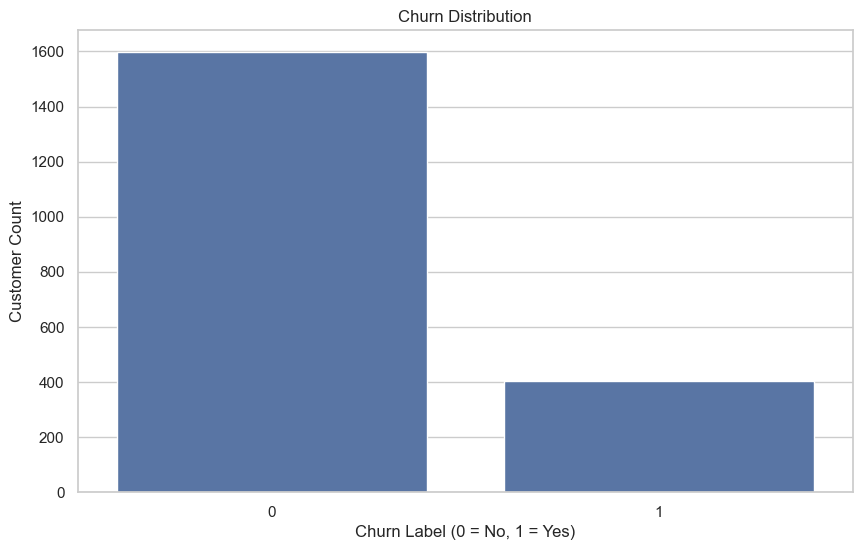

In [25]:
sns.countplot(x='Churn_Label', data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn Label (0 = No, 1 = Yes)')
plt.ylabel('Customer Count')
plt.show()

Age Distribution

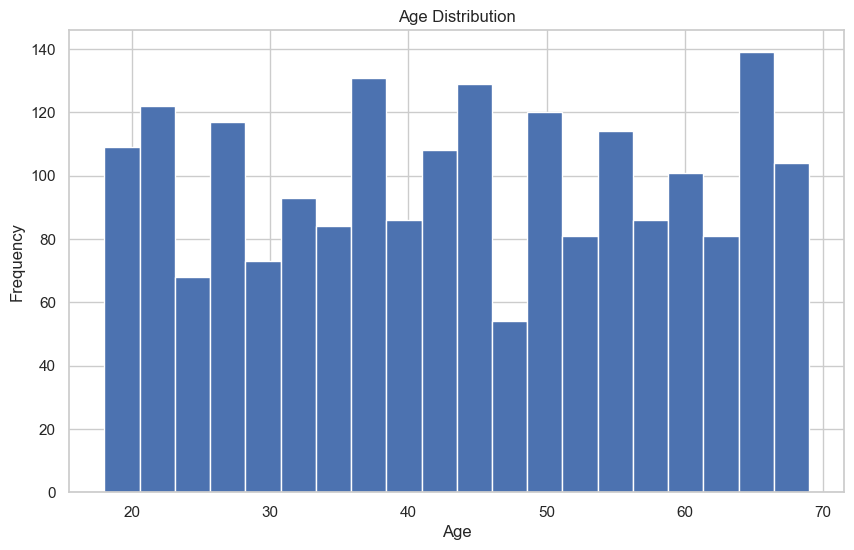

In [26]:
plt.hist(df['Age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Membership tier distribution

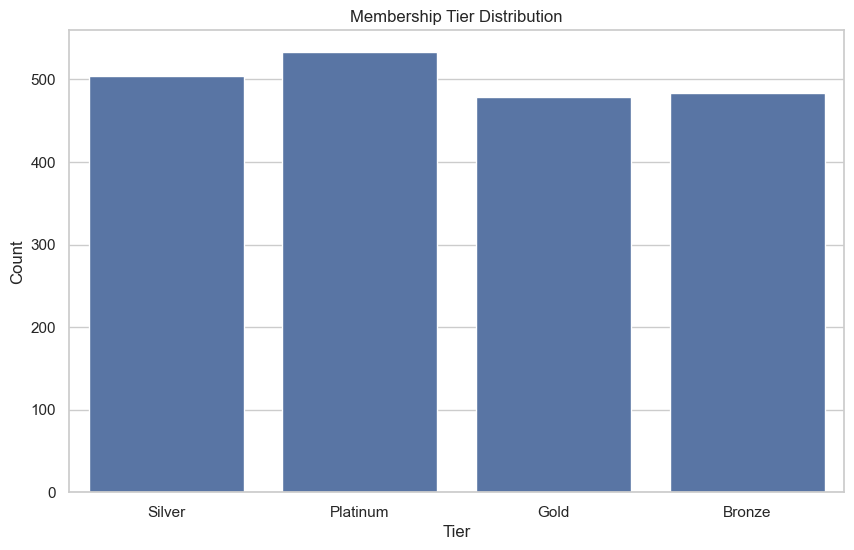

In [27]:
df['Membership_Tier'].value_counts()
sns.countplot(x='Membership_Tier', data=df)
plt.title('Membership Tier Distribution')
plt.xlabel('Tier')
plt.ylabel('Count')
plt.show()


Bivariate Analysis (relationship between two variables)
Churn vs Membership Tier

In [28]:
churn_tier = pd.crosstab(df['Membership_Tier'], df['Churn_Label'])
churn_tier

Churn_Label,0,1
Membership_Tier,,
Bronze,384,100
Gold,393,86
Platinum,411,122
Silver,409,95


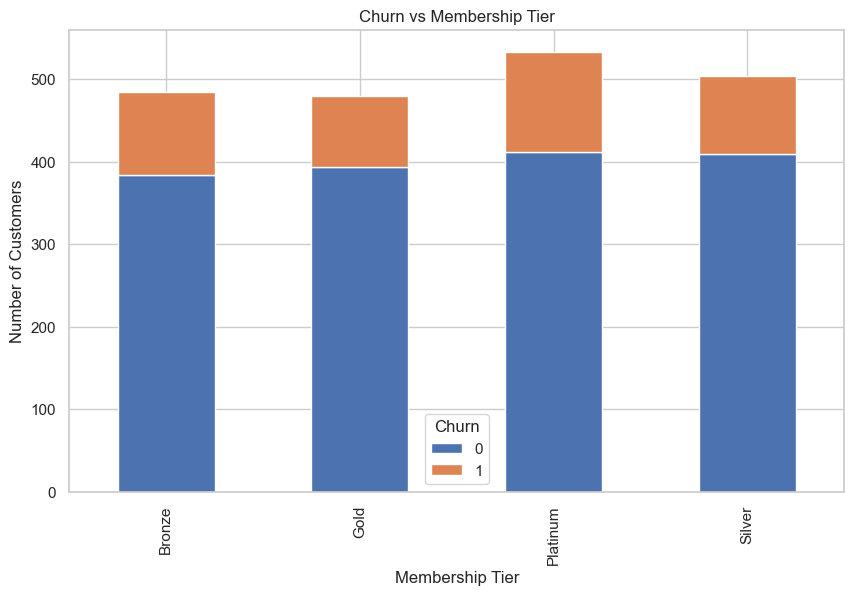

In [29]:
churn_tier.plot(kind='bar', stacked=True)
plt.title('Churn vs Membership Tier')
plt.xlabel('Membership Tier')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

Churn vs Total Spend

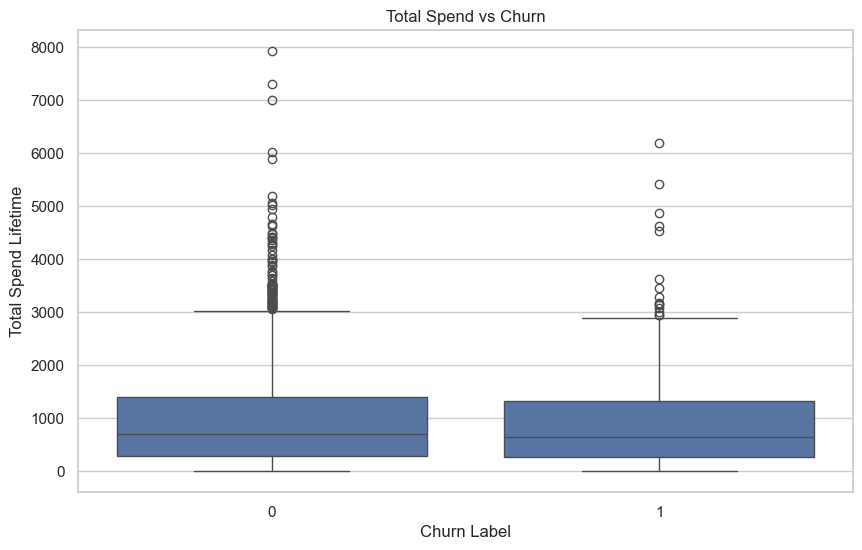

In [30]:
sns.boxplot(x='Churn_Label', y='Total_Spend_Lifetime', data=df)
plt.title('Total Spend vs Churn')
plt.xlabel('Churn Label')
plt.ylabel('Total Spend Lifetime')
plt.show()

Multivariate Analysis
Correlation between numerical features

In [32]:
numeric_cols = [
    'Age',
    'Annual_Income',
    'Total_Spend_Lifetime',
    'Items_In_Cart',
    'Avg_Session_Duration_Min',
    'Customer_Support_Calls']

corr_matrix = df[numeric_cols].corr()
corr_matrix


,Age,Annual_Income,Total_Spend_Lifetime,Items_In_Cart,Avg_Session_Duration_Min,Customer_Support_Calls
Age,1.000000,-0.027643,0.020650,-0.012441,-0.041255,0.002308
Annual_Income,-0.027643,1.000000,-0.009023,0.021174,-0.010390,-0.000241
Total_Spend_Lifetime,0.020650,-0.009023,1.000000,-0.020724,-0.008363,-0.011241
Items_In_Cart,-0.012441,0.021174,-0.020724,1.000000,-0.009032,-0.042915
Avg_Session_Duration_Min,-0.041255,-0.010390,-0.008363,-0.009032,1.000000,0.020621
Customer_Support_Calls,0.002308,-0.000241,-0.011241,-0.042915,0.020621,1.000000


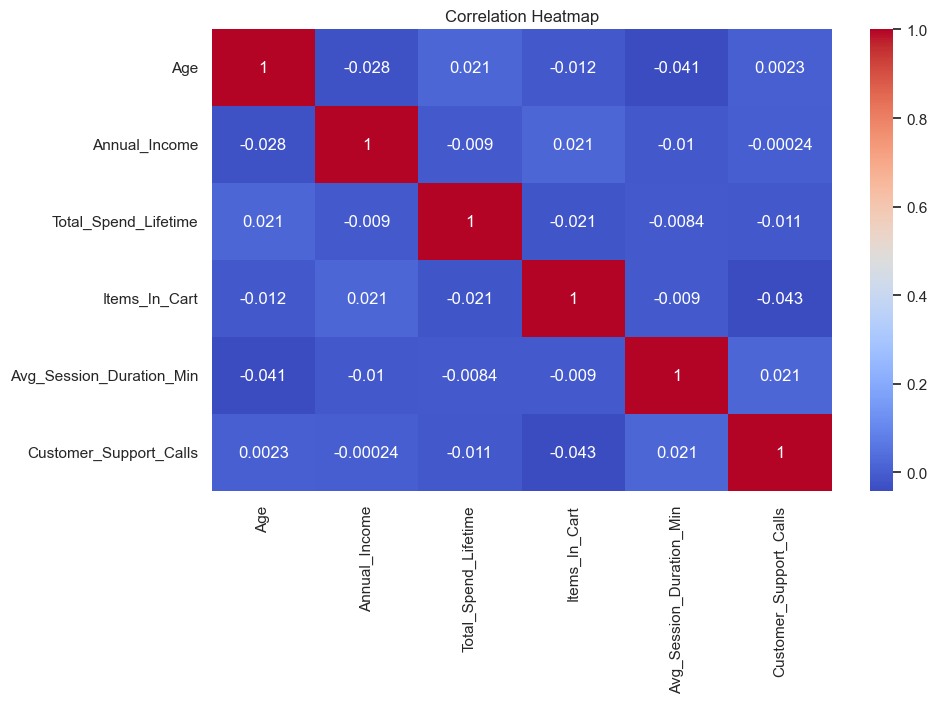

In [33]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Customer behavior by device & churn

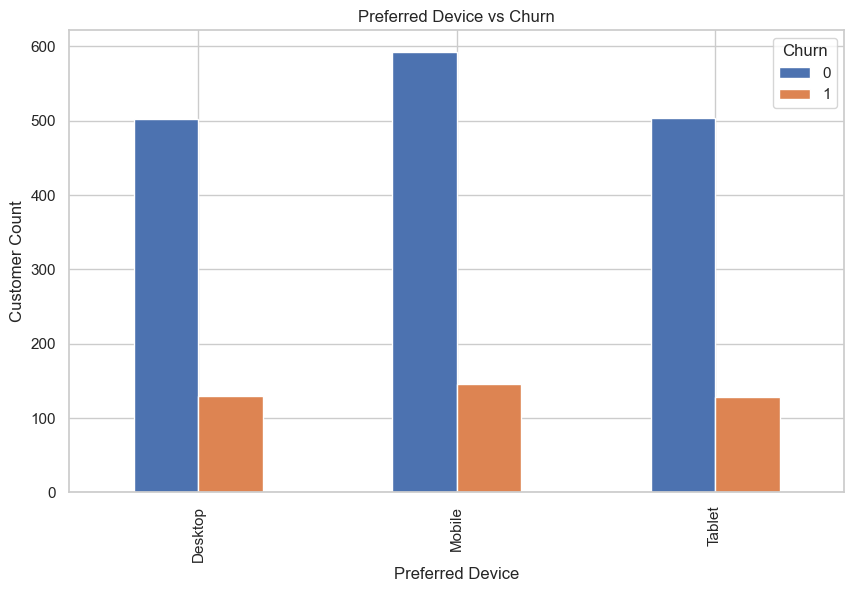

In [34]:
device_churn = pd.crosstab(df['Preferred_Device'], df['Churn_Label'])
device_churn
device_churn.plot(kind='bar')
plt.title('Preferred Device vs Churn')
plt.xlabel('Preferred Device')
plt.ylabel('Customer Count')
plt.legend(title='Churn')
plt.show()

Average spend by membership tier

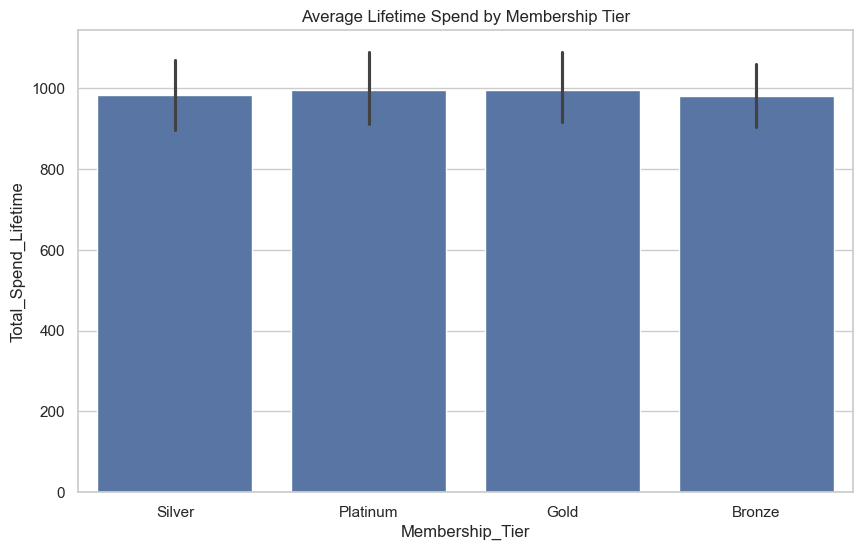

In [35]:
df.groupby('Membership_Tier')['Total_Spend_Lifetime'].mean().sort_values(ascending=False)
sns.barplot(
    x='Membership_Tier',
    y='Total_Spend_Lifetime',
    data=df,
    estimator=np.mean
)
plt.title('Average Lifetime Spend by Membership Tier')
plt.show()

Visualizations

Customer Churn Distribution

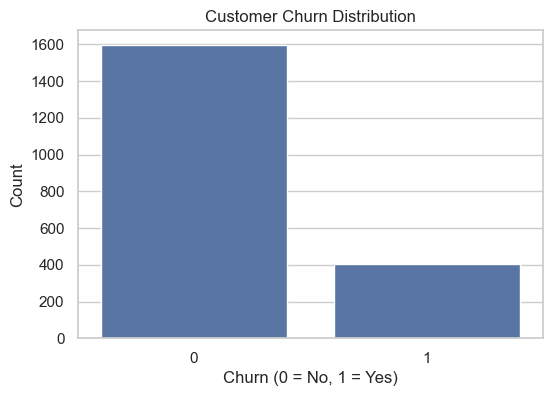

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn_Label', data=df)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

This chart shows the overall distribution of customers who have churned versus those who have not. It helps in understanding whether the dataset is balanced. A significant imbalance indicates potential bias and highlights the need to focus more on churned customers during analysis.

Gender VS Churn

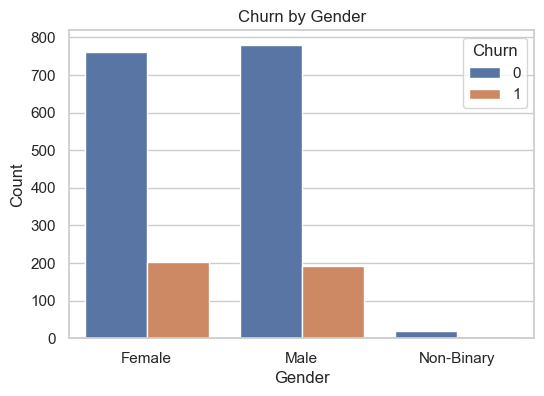

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Churn_Label', data=df)
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.show()

This visualization compares churn behavior across different genders. It helps identify if one gender group is more likely to churn than the other, which can guide targeted retention strategies.

Age Distribution

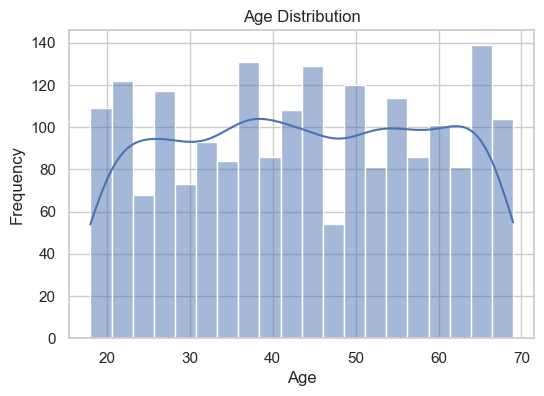

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The histogram illustrates the spread of customer ages. It provides insights into the dominant age groups using the platform and helps identify whether certain age segments are more prevalent.

Income VS Churn

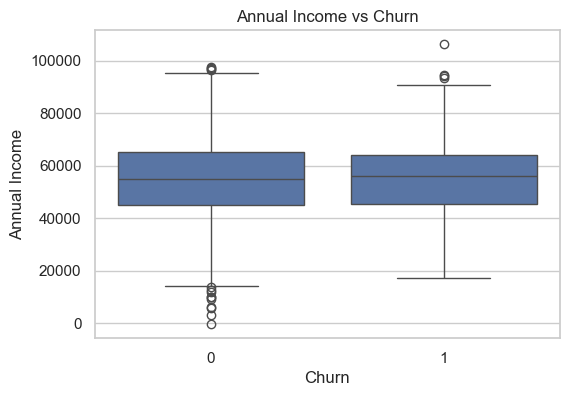

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn_Label', y='Annual_Income', data=df)
plt.title('Annual Income vs Churn')
plt.xlabel('Churn')
plt.ylabel('Annual Income')
plt.show()

This box plot compares income levels between churned and retained customers. It helps determine whether income has any influence on customer retention and whether high-value customers are more or less likely to churn

Membership Tier Distribution

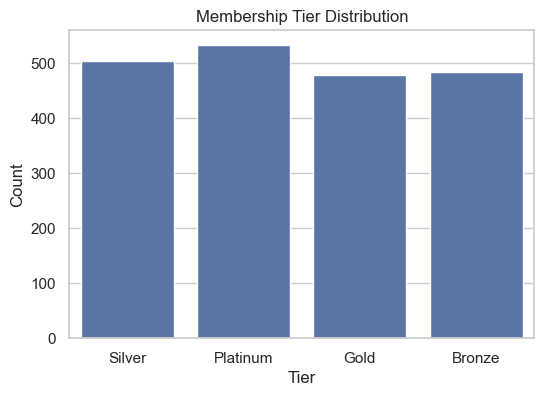

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Membership_Tier', data=df)
plt.title('Membership Tier Distribution')
plt.xlabel('Tier')
plt.ylabel('Count')
plt.show()

This plot shows the number of customers in each membership tier. It helps understand customer segmentation and whether most users belong to lower or higher tiers.

Region wise Distribution

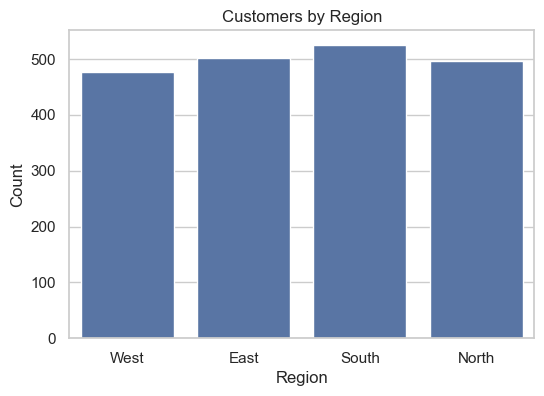

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Location_Region', data=df)
plt.title('Customers by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

This visualization highlights the geographic distribution of customers. It helps identify regions with the highest customer concentration and potential areas for business expansion or targeted marketing.

Total Spend vs Churn

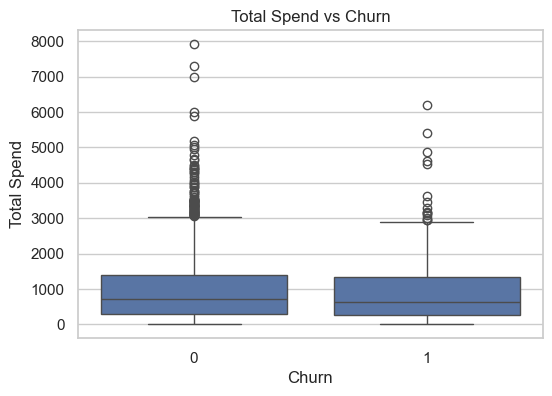

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn_Label', y='Total_Spend_Lifetime', data=df)
plt.title('Total Spend vs Churn')
plt.xlabel('Churn')
plt.ylabel('Total Spend')
plt.show()

This box plot compares the lifetime spending of churned and retained customers. It helps evaluate whether high-spending customers are more loyal or if churn is occurring among valuable customers.

Payment Method Distribution

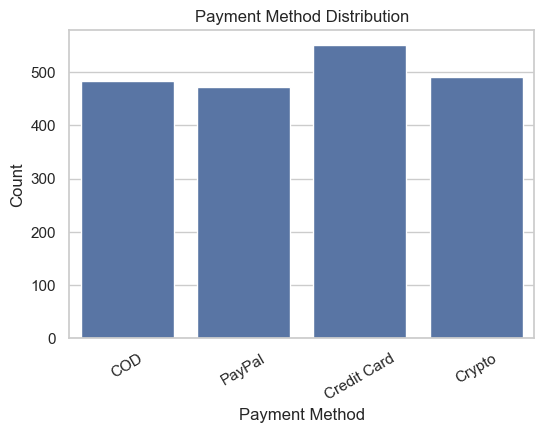

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Payment_Method', data=df)
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

This plot shows the frequency of different payment methods used by customers. It helps identify the most preferred payment options and can guide optimization of payment systems

Correlation Heatmap

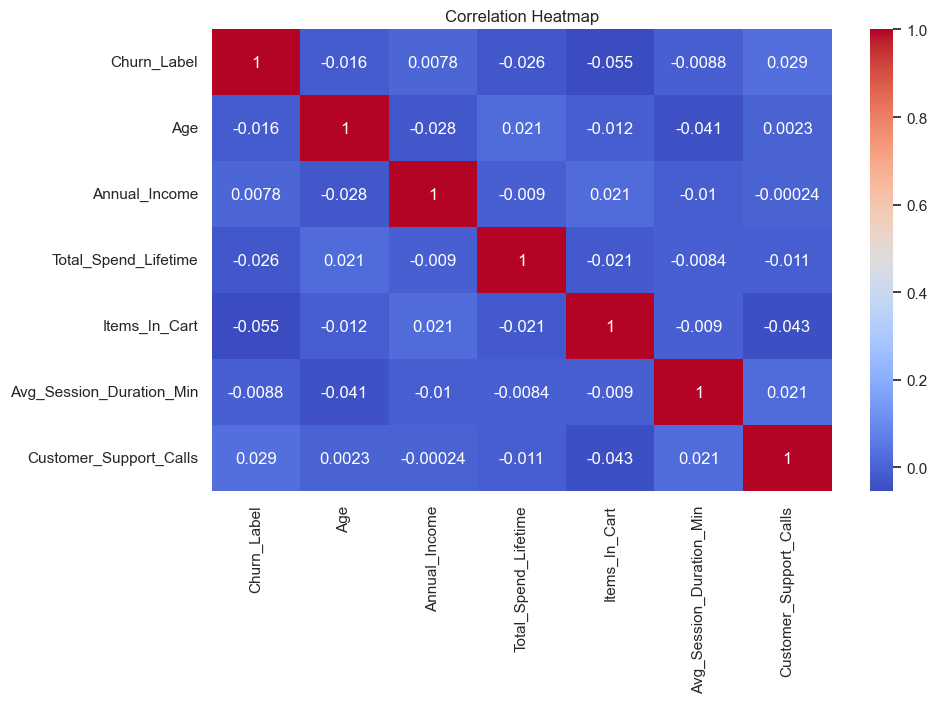

In [11]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The heatmap shows relationships between numerical variables. It helps identify strong positive or negative correlations, which are useful for detecting patterns and potential drivers of churn.

Support calls vs Churn

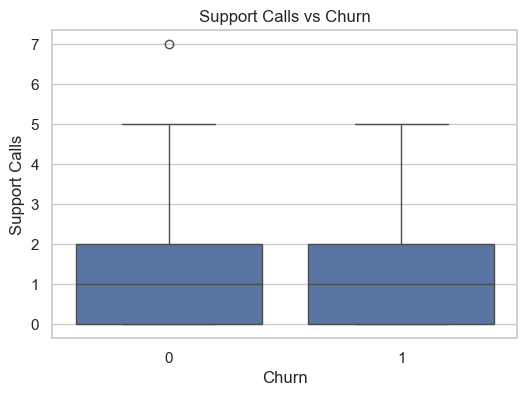

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn_Label', y='Customer_Support_Calls', data=df)
plt.title('Support Calls vs Churn')
plt.xlabel('Churn')
plt.ylabel('Support Calls')
plt.show()

This box plot analyzes the relationship between the number of support calls and churn. A higher number of calls among churned customers may indicate dissatisfaction or unresolved issues

Insights and Report
Project Objective
The objective of this analysis was to understand customer behaviour, identify patterns contributing to churn, and provide data-driven recommendations to improve retention and customer lifetime value in an e-commerce environment.
Key Insights from the Analysis
1️. Customer Churn is Behavior-Driven, Not Demographic-Driven
The analysis shows that churn is not strongly influenced by demographic factors like age or income. Instead, engagement metrics such as session duration and support calls have a stronger relationship with churn.
Interpretation:
Customer experience and interaction quality matter more than who the customer is.
2️. High Number of Support Calls Indicates Dissatisfaction
Customers who contacted support more frequently showed a higher probability of churning.
Interpretation:
Unresolved issues and poor service experience significantly increase churn risk.
3️. Lower Engagement Leads to Higher Churn
Customers with shorter average session durations tend to churn more often.
Interpretation:
Reduced engagement is an early warning signal of potential churn.
4️. High-Value Customers Are Also at Risk
Some customers with high lifetime spending are still churning.
Interpretation:
The business is losing revenue-generating customers due to weak retention strategies.
5️. Majority of Customers Belong to Lower Membership Tiers
The membership distribution indicates most users are concentrated in basic tiers.
Interpretation:
There is an opportunity to upsell and increase customer lifetime value through tier upgrades.
6️. Region-Wise Customer Concentration
Certain regions contribute more customers than others.
Interpretation:
Marketing and retention strategies can be customized region-wise for better impact.

Correlation Analysis Summary
The correlation heatmap indicates:
A positive relationship between support calls and churn.
A negative relationship between session duration and churn.
Limited correlation between demographic variables and churn.
This confirms that behavioral metrics are stronger churn predictors than personal attributes.

 Business Recommendations
1. Improve Customer Support System
Faster resolution time
Proactive follow-ups
Expected Impact: Reduce churn caused by dissatisfaction.
2. Increase Customer Engagement
Personalized product recommendations
Targeted email campaigns
Loyalty reward programs
Expected Impact: Increase session duration and retention.
3. Retain High-Spending Customers
Exclusive offers for premium users
VIP benefits
Early access to sales
Expected Impact: Protect high-revenue segments.
4. Encourage Membership Upgrades
Discounts for upgrading tiers
Points-based reward system
Expected Impact: Increase average revenue per customer.
5. Region-Specific Strategy
Focus marketing budget on high-performing regions
Improve services in low-retention areas
Expected Impact: Balanced growth and improved regional performance.
Final Conclusion
This analysis demonstrates that customer churn in the e-commerce platform is primarily influenced by engagement levels and service experience rather than demographic characteristics. Customers with lower interaction levels and higher support complaints are more likely to churn.
By improving customer support, increasing engagement, and implementing targeted retention strategies, the company can significantly reduce churn, protect high-value customers, and improve overall profitability.